# **ENGG680 - Introduction to Digital Engineering**
## *Lab Assignment 2: Introduction to Non-linear Square and Machine Learning*

## Preliminary: Certificate of Work (5 marks)


*We, the undersigned, certify that this is our own work, which has been done expressly for this course, either without the assistance of any other party or where appropriate we have acknowledged the work of others. Further, we have read and understood the section in the university calendar on plagiarism/cheating/other academic misconduct and we are aware of the implications thereof. We request that the total mark for this assignment be distributed as follows among group members:*

|          | First Name | Last Name | Signature (Full Name, Date)| Contribution % |
|----------|------------|-----------|-----------------------------|----------------|
| Member 1: | Kara | Fitzgerald | K.Fitzgerald 18,Nov | 25% |
| Member 2: | Shehrukh	| Wasif | S.Wasif 24,Nov | 25% |
| Member 3: | Tami | Adeleke | t.adeleke, 23 Nov | 25% |
| Member 4: | Muhammad Anas | Nawaz | Signature | 25% |


# **PART 1: Non-linear Estimation - LSE & Gradiant Decent (35 Marks)**

The following materials will be our states of interest, and we are going to estimate them using **Least Square method** and **Gradient Descent method**

## **SinglePointPositioning Formulas**

### **Observations:** Pseudorange [m]

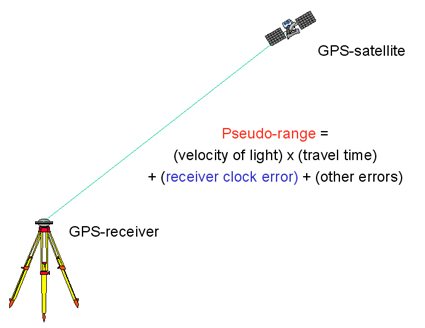

<font size="1.5">Image source: *ICA Course on Toponymy. https://unstats.un.org/unsd/geoinfo/ungegn/docs/_data_icacourses/_HtmlModules/_Selfstudy/S06/S06_05b.html.*</font>

**Pseudorange** is the *pseudo* distance between a satellite and a satellite signal receiver on the ground. In simple words, it contains the geometric range between the satellite and the receiver, with additional associated errors.

The simplified version of the Pseudorange measurement model is:
$$P=\rho-cdT+ϵ_{sum}$$ and
$$\rho=\sqrt{(x_s - x_r)^2 + (y_s - y_r)^2 + (z_s - z_r)^2}$$
where
$$\rho=geometric\ range$$
$${x_s, y_s, z_s, x_r,y_r,z_r} = 3D\ coordinates\ of\ satellite\ and\ receiver$$
$$cdT = receiver\ clock\ offset$$
$$ϵ_{sum}=general\ errors\ term\ (ϵ_{sum}=\Delta \rho + \Delta_{\text{ion}} + \Delta_{\text{trop}} + \epsilon_P + cdt)$$

\
Note: the 3D **positions of satellites** are given in this assignment.

### **Unknown States:** Position of receiver & receiver clock offset

We use the psuedorange measurements to estimate the receiver's **3-dimensional position** and the **receiver clock offset:** $$X={x_r,y_r,z_r,cdT}$$.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **Setup & Intialization for LSE and Gradient Decent (5 Marks)**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
%cd /content/drive/MyDrive/ENGG680_2025_Fall


/content/drive/MyDrive/ENGG680_2025_Fall


In [ ]:
# Load the psuedorange measurements and satellites' positions files, store them in the format of numpy array
# Add small random perturbations in the range (0, 0.5) to pseudorange measurements to simulate measurement noise
# (hint: use pandas library to parse excel files into dataframe first, then convert them to numpy arrays)
# (1 marks)


#importing pseudorange excel file with the pd funciton
df_pseudorange = pd.read_excel("Lab_Assignment_2/part1_data/pseudoranges.xlsx")
#importing satellite position
df_sat_pos = pd.read_excel("Lab_Assignment_2/part1_data/satellite_position.xlsx")

np.random.seed(42)  # For reproducible results

#storing excel file as numpy array
pseudorange = np.array(df_pseudorange)
#remove satellite id column for processsing
pseudorange = np.delete(pseudorange, np.s_[0:1], axis=1)

sat_pos = np.array(df_sat_pos)
#same thing for this one
sat_pos = np.delete(sat_pos, np.s_[0:1], axis =1)


In [ ]:
# define the number of measurements n and the number of unknown states m
# (2 mark)

#number of measurements is reflected by the number of rows of data points in the pseudorange set
n = len(df_pseudorange)

#based on the formula provided above where we have x,y,z coordinates and reciever clock offset
m = 4


In [ ]:
# GroundTruth coordiantes of the receiver
GroundTruth=np.array([-1633489.37967725,	-3651627.18250363,	4952481.61954918])

In [ ]:
# define a function called euclidean_norm, which computes the geometric distances between satellites and receiver
# the input of the function should be two arrays: receiver_pos and satellite_pos
# the function should return an array of distance between satellites and receiver
# you can either use the numpy function or code the math manually
# (2 marks)
# get numpy arrays
#compute distances and output dynamic array sizing

def euclidean_norm(receiver_pos, satellite_pos):
    # receiver_pos must be shape (1,3)
    diff = satellite_pos - receiver_pos[0,:3]
    #dynamic resizing
    distance = np.linalg.norm(diff, axis=1).reshape(-1,1)
    return distance

## **Non-linear LSE (15 Marks)**

### Step 1: Given that the variance of observation is 1.2 (m^2), define the weight matrix P (0.5 marks)

In [ ]:
#weight matrix is the inverse of the covariance matrix based on n, where variance = 1.2
#inverting gives 1/1.2

P = (1/1.2)* np.identity(n)

### Step 2: set the initial states as [100.0, -50.0, 25.0, 1000.0] (0.5 mark)

In [ ]:
#set the initial values as outlined above in line with m dimensions
x_0 =np.array([100.0,-50.0,25.0,1000.0]).reshape(1,4)

### Step 3: initialize the corrections array as 10s, iteration loop counter i as zero and related arrays (1 mark)

In [ ]:
#set correction array to 10s
delta = np.array([10.0, 10.0, 10.0, 10.0])

#setting iterating loop counter to 0
i = 0

#given empty arrays to store results (no need to fill anything here)
arr_w = []
arr_delta=[]
arr_err_pos = []
arr_i = []
x_hat = []

### Step 4: define a function named design_matrix which computes the design matrix A of this LSE problem (3 mark)

the input of this funciton should be: estimated unknown states array, satellites positions array and geometric distance array

the function should return an two-dimensional array which represents the design matrix A

#### Calculation Formula for the Design Matrix \( A \)

Let the position vectors of the satellite and receiver be:

- **r** = (r_x, r_y, r_z) for the receiver
- **s** = (s_x, s_y, s_z) for the satellite

The Euclidean distance between the satellite and receiver is given by:

$$
\rho = \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2}
$$

#### Partial Derivatives of the Distance with Respect to \(x\), \(y\), and \(z\):

To construct the design matrix, we compute the partial derivatives of the distance function with respect to the receiver's \(x\), \(y\), and \(z\) coordinates. Here's the detailed process for one of them, and the others follow the same procedure.

##### Partial derivative with respect to \(r_x\):

Taking the derivative with respect to \(r_x\), we use the chain rule:

$$
\frac{\partial \rho}{\partial r_x} = \frac{\partial}{\partial r_x} \left( \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2} \right)
$$

First, apply the derivative of the square root:

$$
\frac{\partial \rho}{\partial r_x} = \frac{1}{2 \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2}} \cdot 2 (r_x - s_x)
$$

Simplifying:

$$
\frac{\partial \rho}{\partial r_x} = \frac{r_x - s_x}{\rho}
$$

##### Partial derivatives for \(r_y\) and \(r_z\):

The partial derivatives with respect to \(r_y\) and \(r_z\) follow the same procedure:

$$
\frac{\partial \rho}{\partial r_y} = \frac{r_y - s_y}{\rho}
$$

$$
\frac{\partial \rho}{\partial r_z} = \frac{r_z - s_z}{\rho}
$$

#### The Design Matrix \(A\):

Thus, the design matrix \(A\) can be expressed as:

$$
A = \left[
\begin{array}{ccc|c}
\frac{s_x - r_x}{\text{distance}} & \frac{s_y - r_y}{\text{distance}} & \frac{s_z - r_z}{\text{distance}} & -1
\end{array}
\right]
$$

Where:
- The first three columns represent the partial derivatives of the distance with respect to x, y, and z coordinates
- The last column of -1 corresponds to the constant term in the least squares equation

This matrix is used for least squares estimation in positioning or navigation applications.


In [ ]:


def design_matrix(receiver_pos, satellite_pos, distance):
    r_x, r_y, r_z, _ = receiver_pos[0, :]
    n = satellite_pos.shape[0]

    #vectorized columns
    c1 = (r_x - satellite_pos[:,0]) / distance[:,0]
    c2 = (r_y - satellite_pos[:,1]) / distance[:,0]
    c3 = (r_z - satellite_pos[:,2]) / distance[:,0]
    c4 = -np.ones((n,))

    # stack columns horizontally
    A = np.column_stack((c1, c2, c3, c4))
    return A




### Step 5: start the iteration for the LSE (4 mark)

define the convergence criteria for the 'while' loop

the convergence criteria is that the corrections delta are less than 0.008 (i.e., <0.1 m), for receiver's position x,y,z part

In [ ]:

#loop to stop when convergence of first 3 elements (x,y,z) is small (0.008)
while np.linalg.norm(delta[:3]) > 0.008:

       # compute the geometri distance between Satellites and receiver, using the euclidean_norm function we just defined
       # (0.5 marks)
       #input the initial values outlined above and the satellite position array imported from excel
       distance = euclidean_norm(x_0, sat_pos)

       # compute the design matrix A
       # (0.5 marks)
       #desing matrix based on initial values, sat position and distance
       A = design_matrix(x_0, sat_pos, distance)


       # compute the misclosure array w
       # (0.5 marks)
       #misclosure = difference between observed pseudoranges P and computed distances
       w = pseudorange.reshape(-1,1) - distance + x_0[0,3]

       # compute the corrections delta
       # (0.5 marks)
       #weight p to account for variance
       #delta = (A.T*P*A)inverse*A.T*P*W
       delta = np.linalg.inv(A.T @P @A) @ (A.T @ P @w)

       # update the states
       x_hat = x_0 + delta.T
       x_0 = x_hat.copy()



       # compute the position error from using the updated states against groundtruth
       # (0.5 marks)
       #assume postion error as single scalar
       err_pos = GroundTruth - x_hat[0,:3]


       # update the counter i, (i.e., increament of 1 for each iteration)
       i +=1

       # store the misclosure, delta, position error and counter from each iteration into arrays, we will use them for plotting
       # (0.5 marks)
       arr_w.append(w)
       arr_delta.append(delta.T)
       arr_err_pos.append(err_pos)
       arr_i.append(i)


# After convergence, compute the A Posteriori Variance of Unit Weight
# (0.5 marks)
#residual after last iteartion
v= w-A @delta
#unit of weight
apv = (v.T @ P @ v)/(n-m)

# compute the Covariance matrix of estimated states
# (0.5 marks)
C_x_hat = apv * np.linalg.inv(A.T @ P @ A)




### Step 6: Results Printing (1 mark)

Print:

* estimated states,
* corrections array,
* estimated measurements residuals,
* A posteriori Variance of Unit Weight,
* Covariance matrix of estimated states,
* number of iterations,
* 3-D position errors


In [ ]:
# your code here

print('The values after the final iteration are as follows\n')
print(f"Estimated States: {x_hat}\n")
print(f"Corrections Array (delta):\n {delta}\n")
print(f"Estimated Measurements Residuals (w):\n {w}\n")
print(f"A Posteriori Variance of Unit Weight: {apv}\n")
print(f"Covariance Matrix of Estimated States:\n{C_x_hat}\n")
print(f"Number of Iterations:\n {i}\n")
print(f"3-D Position Errors:\n {err_pos}")


The values after the final iteration are as follows

Estimated States: [[-1.63349244e+06 -3.65162954e+06  4.95248543e+06 -6.47201390e+00]]

Corrections Array (delta):
 [[ 3.23143675e-06]
 [ 6.39725190e-06]
 [-1.75939080e-05]
 [ 2.09174512e-05]]

Estimated Measurements Residuals (w):
 [[ 0.25995968]
 [ 0.11116657]
 [-1.09951518]
 [-0.00500947]
 [ 0.2003028 ]
 [-1.41816898]
 [-0.09127866]
 [ 1.51207884]
 [ 0.26364719]
 [ 0.61137232]
 [-0.34467609]]

A Posteriori Variance of Unit Weight: [[0.73774071]]

Covariance Matrix of Estimated States:
[[ 0.28298264  0.06167139 -0.07487066  0.06468701]
 [ 0.06167139  0.37666273 -0.51441611  0.32601524]
 [-0.07487066 -0.51441611  1.81094828 -0.9773772 ]
 [ 0.06468701  0.32601524 -0.9773772   0.61904475]]

Number of Iterations:
 5

3-D Position Errors:
 [ 3.06483961  2.3598758  -3.81315917]


### Step 7: Comment on the computed A Posteriori Variance of Unit Weight value and the Covariance matrix of estimated states (1 mark)

In [ ]:
#A value of the Posteriori Variance of Unit Weight of 1 indicates a good fit of the model, we would assume
#the measurement noise isslightly below the assumed unit weight. Value obtained is 0.7377.

#For the Covariance matrix;
#The estimated positions in x and y are fairly precise, z is less precise, which is common in GPS due to satellite geometry (GDOP effect).

#Clock bias variance is moderate, consistent with pseudorange weighting.

#The matrix shows that the states are correlated, so improvements in measurement or geometry would reduce these correlations and overall errors.




### Step 8: Using the imported matplotlib, plot the following. Make sure to include proper axes information, legend, grid lines and title. (3 marks)

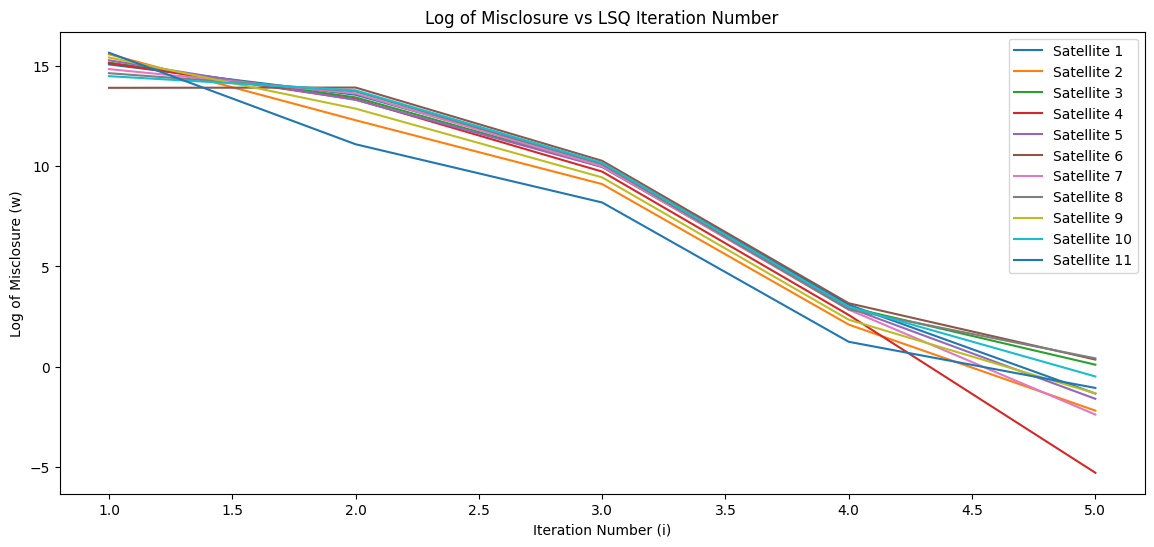

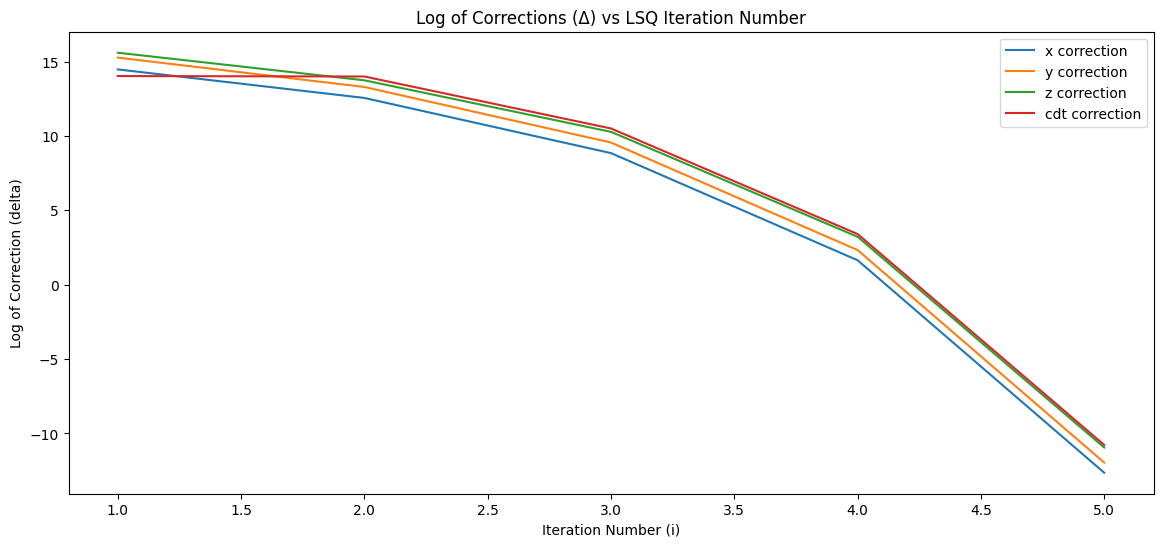

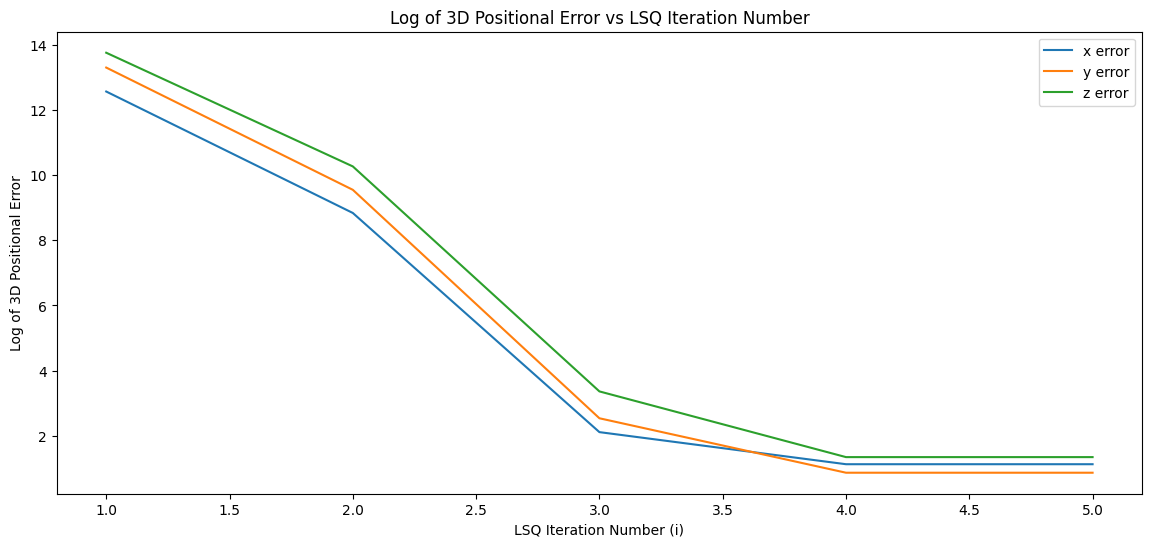

In [ ]:
# 1. Plot log of the misclosure w against the LSQ iteration number i
# (1 marks)

# Shape becomes (num_iterations, num_satellites) to be compatible
arr_w_np = np.concatenate(arr_w, axis=1).T  # transpose so iterations = rows

# Create figure
plt.figure(figsize=(14, 6))

# Plot log misclosure for each satellite over iterations
for sat in range(arr_w_np.shape[1]):
    plt.plot(arr_i, np.log(np.abs(arr_w_np[:, sat])), label=f'Satellite {sat+1}')

# plot labels/characteristics
plt.xlabel('Iteration Number (i)')
plt.ylabel('Log of Misclosure (w)')
plt.title('Log of Misclosure vs LSQ Iteration Number')
plt.legend()
plt.show()


# 2. Plot log of the corrections delta against the LSQ iteration number i
# (1 marks)
# Convert list of correction arrays into a 2D NumPy array
arr_delta_np = np.vstack(arr_delta)

# Create a figure
plt.figure(figsize=(14,6))

# Loop through each unknown (x, y, z, clock bias)
labels = ['x correction', 'y correction', 'z correction', 'cdt correction']
for j in range(arr_delta_np.shape[1]):
    #absolute first to avoid negative logs
    plt.plot(arr_i, np.log(np.abs(arr_delta_np[:, j])), label=labels[j])

# Plot settings
plt.xlabel('Iteration Number (i)')
plt.ylabel('Log of Correction (delta)')
plt.title('Log of Corrections (Δ) vs LSQ Iteration Number')
plt.legend()
plt.show()



# 3. Plot log of the 3D position errors against the LSQ iteration number i
# (1 marks)

# Shape ajustment
arr_err_np = np.vstack(arr_err_pos)

# Create figure
plt.figure(figsize=(14, 6))

#labels for error components
labels = ['x error', 'y error', 'z error']

# Plot log misclosure for each satellite over iterations
for i in range(arr_err_np.shape[1]):
    plt.plot(arr_i, np.log(np.abs(arr_err_np[:, i])), label=labels[i])

# plot labels/characteristics
plt.xlabel('LSQ Iteration Number (i)')
plt.ylabel('Log of 3D Positional Error')
plt.title('Log of 3D Positional Error vs LSQ Iteration Number')
plt.legend()
plt.show()


### Step 9: Describe the phenomena or pattern you recognize for each plot, and explain such phenomena (1 marks)

In [ ]:
#log of the misclosure:
# we see that the values steadily decreases as the iteration number increases, starting large and dropping quickly
#this suggests improved alignement, and the flattening happens as the system converges.
#This is the result of the iterative method used is LS, asjuting both reciever position and offset estimation


#correction magnitudes:
#decrease rapidly over the first few iterations then approach near zero and remain stable
#represents how much the estimated states are adjusted at each step. Large corrections indicate large divergence from teh solution
#when the convergence criterion is met, that is the stabalitzation of the system seen with the near-0 values


#Positional errors:
#decrease on log scale with each iterative count
#z converges more slowly than x and y coordinates
# demonstrates the improvement of the solution with each iteration
#diminishing change shows minimization of positional error


### Bonus: this is just for fun (no marks allocated)

now that you have estimated the receiver's position in Earth-center-earth-fixed (ECEF)

you can use this tool: https://www.oc.nps.edu/oc2902w/coord/llhxyz.htm to convert it to latitude, longitude and height

and find where is it on google earth!

## **Non-linear Gradient Decent (15 Marks)**

### Step 0: Intialize empty arrays (there is no need to fill anything here)

In [ ]:
arr_cost= []
arr_grad= []
arr_err=[]
steps_count=0

### Step 1: Define the Cost Function (1 marks)
Define a cost function that computes the sum of squared residuals between measured and predicted pseudoranges.

The function's inputs are: the receiver's coordinates, clock offset, satellites' coordinates, observed pseudoranges.

The function returns a single scalar.

Call euclidean_norm function to calculate geometric distance.

In [ ]:
# Cost function: sum of squared residuals between measured and predicted pseudoranges
#sum (obs-predicted)^2

def cost_function(rec_pos, cdT, sat_pos, pseudorange):
    # ensure 1D
    rec_pos = np.asarray(rec_pos).flatten()
    #define reciever coordinates
    x_r, y_r, z_r = rec_pos
    #distance value
    pred_dis = euclidean_norm(np.array([rec_pos]), sat_pos)
    #sum squared residual
    L= np.sum((pseudorange - (pred_dis - cdT))**2)
    return L

### Step 2: Define the Gradient Computation Function (1 marks)

Define a gradient computation function that calculates the gradient of the cost function with respect to the estimates (x_r, y_r, z_r, cdT).


The function's inputs are: the receiver's coordinates, clock offset, satellites' coordinates, observed pseudoranges.


The function returns a 1D numpy array that contains 4 elements.


Call euclidean_norm function to calculate geometric distance.


**Recall elements of the design matrix A in the previous LSE function.**

In [ ]:
# Gradient of the cost function with respect to the unknowns (x_r, y_r, z_r, cdT)
def gradient(rec_pos, cdT, sat_pos, pseudorange):
    # compute geometric distances
    #rho = euclidean_norm(rec_pos[np.newaxis, :], sat_pos).reshape(-1)
    rec_pos = np.asarray(rec_pos).flatten()

    #original attempt
    #rho = euclidean_norm(np.array([rec_pos]), sat_pos).flatten()
    #updated to try and fix debugging
    pr = np.asarray(pseudorange).reshape(-1)
    rho = euclidean_norm(np.array([rec_pos]),sat_pos).reshape(-1)

    # residuals
    residuals = pseudorange - (rho + cdT)
    #partials derivatives
    dx = (rec_pos[0] - sat_pos[:, 0]) / rho
    dy = (rec_pos[1] - sat_pos[:, 1]) / rho
    dz = (rec_pos[2] - sat_pos[:, 2]) / rho
    #gradient compoenents
    dJ_dx = -2 * np.sum(residuals * dx)
    dJ_dy = -2 * np.sum(residuals * dy)
    dJ_dz = -2 * np.sum(residuals * dz)
    dJ_dcdT = -2 * np.sum(residuals)

    grad = np.array([dJ_dx, dJ_dy, dJ_dz, dJ_dcdT])
    return grad



### Step 3: Gradient Descent Implementation (4 marks)
Construct the implementation function of gradient descent

Replace '...' with actual implementation

The function's input are: observed pseudoranges, satellites' positions, learning_rate, maximum loop iterations, tolerance

The function will return a 1D numpy array that contains the optimized estimates (x_r, y_r, z_r, cdT)

The function set learning_rate, max_iters and tolerance as: 0.08, 10000, 8e-7 as default values

These default hyperparameters values can be overridden by passing your own values when calling the function


In [ ]:
# Gradient descent algorithm for non-linear least squares estimation
def gradient_descent(pseudorange, sat_pos, learning_rate=0.08, max_iters=10000, tolerance=8e-7):

    global steps_count

    #initalize the estimates as zeros
    X = np.array([50.0, -25.0, 15.0, 500.0])

    for iteration in range(max_iters):
        rec_pos = X[:3]
        cdT = X[3]

        # compute the cost in the current step
        # (1 mark)
        #pass gradient_descent function variables to the cost function
        current_cost = cost_function(rec_pos, cdT, sat_pos, pseudorange)


        # compute the gradients in the current step
        # (1 mark)
        #pass gradient_descent variables to the gradient function
        grad = gradient(rec_pos[np.newaxis, :], cdT, sat_pos, pseudorange)


        # update estimates
        # (1 mark)
        #new gradient is current value- old gradient, with learning rate constant applied
        X_new = X - learning_rate * grad


        # compute the new cost
        # (1 mark)
        #call cost function again but with upadted positional values from X_new
        new_cost = cost_function(X_new[:3][np.newaxis, :], X_new[3], sat_pos, pseudorange)


        # break the loop if converge
        if np.abs(new_cost - current_cost) < tolerance:
            print("Converged !")
            steps_count=iteration
            break

        # update the parameters for the next iteration
        X = X_new

        #collect intermediate results for cost and gradients
        arr_cost.append(current_cost)
        arr_grad.append(grad)
        arr_err.append(X[:3]-GroundTruth)

    return X

### Step 4: Parameters Optimization & Results Printing (2 marks)

Call *gradient_descent* function to optimize the estimating parameters using default optimization hyperparameters

Print:

*   optimized parameters
*   final position errors of receiver
*   number of steps taken for convergence
*   final cost value
*   final gradient values








In [ ]:
#calculating optimized paramaters based on the pseudorange and satellite position
optimized_params = gradient_descent(pseudorange, sat_pos)

#Extract positional and cdt parameters from the output
est_pos = optimized_params[:3]
est_cdT = optimized_params[3]

# final error calculation
pos_error_vec = GroundTruth - est_pos
pos_error_mag = np.linalg.norm(pos_error_vec)

# final cost and gradient
final_cost = cost_function(est_pos, est_cdT, sat_pos, pseudorange)
final_grad = gradient(est_pos, est_cdT, sat_pos, pseudorange)

# Print
print(f"Optimized Parameters [x, y, z, cdT]: {optimized_params}")
print(f"Final Receiver Position Error Vector (m): {pos_error_vec}")
print(f"3D Position Error Magnitude (m): {pos_error_mag:.6f}")
print(f"Number of Steps Taken: {steps_count}")
print(f"Final Cost Value: {final_cost:.6f}")
print(f"Final Gradient Values: {final_grad}")

Converged !
Optimized Parameters [x, y, z, cdT]: [ 1.14824075e+16  2.83610057e+16 -7.15778566e+16 -7.98221039e+16]
Final Receiver Position Error Vector (m): [-1.14824075e+16 -2.83610057e+16  7.15778566e+16]
3D Position Error Magnitude (m): 77843316183403408.000000
Number of Steps Taken: 12
Final Cost Value: 273442231716928514008306066265210880.000000
Final Gradient Values: [-7.06360182e+16 -1.74467638e+17  4.40323582e+17 -4.78866642e+17]


### Step 5: Cost vs Steps Plot & Analysis (1 marks)
Plot cost vs steps

Use 'semilogy' to scale y-axis

Label each axis

Include figure title

Comment on the pattern from the plot

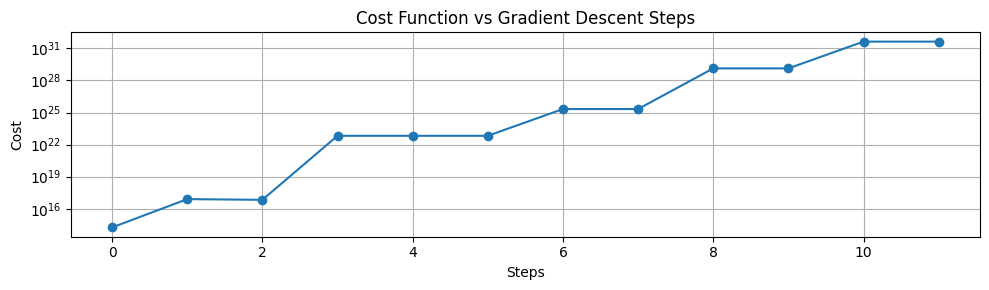

In [ ]:
fig , ax = plt.subplots(nrows=1,ncols=1, figsize=(10,3))
# (0.5 marks)
# plot cost vs steps
#steps until convergence
steps = range(steps_count)
ax.semilogy(steps, arr_cost[:steps_count], marker = "o", linestyle ="-")
ax.set_xlabel("Steps")
ax.set_ylabel("Cost")
ax.set_title("Cost Function vs Gradient Descent Steps")
ax.grid(True)
fig.tight_layout()
plt.show()

# Comment on the pattern (0.5 marks)
#The cost function does not decrease over the gradient descent steps.
#The cost grows exponentially, indicating divergence
# the learning rate may be too large, or the inital guess insufficent.


### Step 6: Gradients vs Steps & Analysis(1 marks)
Plot gradients vs steps

use 'symlog' to scale y-axis

use 'tick_params' and set y-axis: labelsize=8

include axes' labels, legends and title

Comment on the pattern from the plot

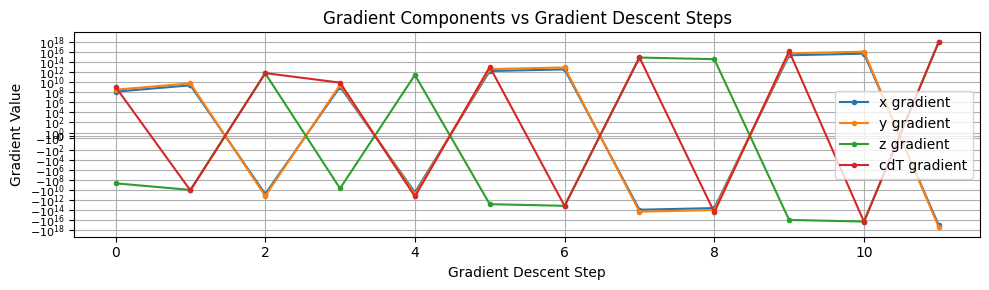

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 3))

# Convert- easier slicing
arr_grad_np = np.array(arr_grad)
steps = range(arr_grad_np.shape[0])

# gradient component vs step number
ax.plot(steps, arr_grad_np[:, 0], label='x gradient', linestyle='-', marker='.')
ax.plot(steps, arr_grad_np[:, 1], label='y gradient', linestyle='-', marker='.')
ax.plot(steps, arr_grad_np[:, 2], label='z gradient', linestyle='-', marker='.')
ax.plot(steps, arr_grad_np[:, 3], label='cdT gradient', linestyle='-', marker='.')

# so small and large values are visible, even if negative
ax.set_yscale('symlog')

# Set parameters
ax.set_xlabel('Gradient Descent Step')
ax.set_ylabel('Gradient Value')
ax.set_title('Gradient Components vs Gradient Descent Steps')
ax.legend()

# Adjust tick label size for y-axis
ax.tick_params(axis='y', labelsize=8)


ax.grid(True)
fig.tight_layout()
plt.show()

# Comment on the pattern
# There is large oscillation indicating the the model is not stable.
# the model is not appraoching 0, meaning it does not represent a mininum.
#



### Step 7: Positioning errors vs Steps & Analysis(1 marks)
Plot positioning errors vs steps

Include axes' labels, legends and title

Comment on the pattern of the plot

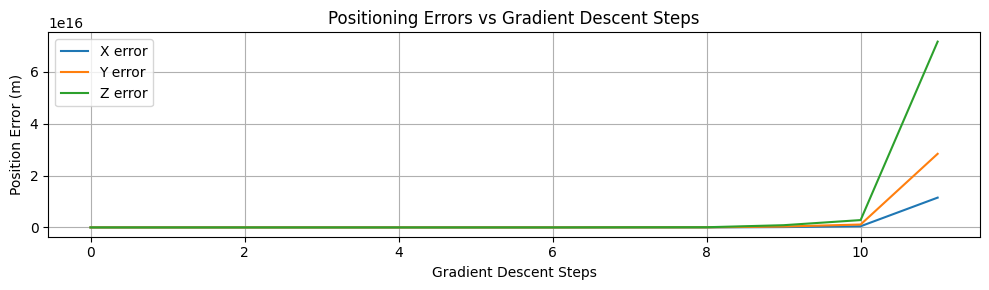

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 3))

# numpy array for plotting
arr_err_np = np.array(arr_err)
steps = np.arange(len(arr_err_np))

# Plot each component of the position error
ax.plot(steps, np.abs(arr_err_np[:, 0]), label='X error')
ax.plot(steps, np.abs(arr_err_np[:, 1]), label='Y error')
ax.plot(steps, np.abs(arr_err_np[:, 2]), label='Z error')

# Axis labels and title
ax.set_xlabel("Gradient Descent Steps")
ax.set_ylabel("Position Error (m)")
ax.set_title("Positioning Errors vs Gradient Descent Steps")

# Legend and grid
ax.legend()
ax.grid(True)
fig.tight_layout()
plt.show()

# Comment on the pattern
# (0.5 marks)

#the position errors remain nearly constant for the first several iterations,
#then increase rapidly toward extremely large values.
# expected behavior would be to decrease towards a 0 value
#This indicates that the gradient descent algorithm is diverging rather than converging
# and is consistent with the behaviro shown above.
#The cause is likely an excessively large learning rate


### **Hyperparameters Tuning**

### Step 8: Tuning Learning rate (2 marks)

Change learning rate to 0.008, 0.0008 and repeat step 4.

(*hint: you may need to adjust the maximum loop iterations in this case*)

In [ ]:
# Set learning
learning_rate = 0.008

# Re-initialize arrays and counters
arr_cost = []
arr_grad = []
arr_err = []
steps_count = 0

# Run gradient descent with the new learning rate
optimized_params_2 = gradient_descent(pseudorange, sat_pos, learning_rate=learning_rate, max_iters=70000, tolerance=8e-7)

# Extract components
est_pos_2 = optimized_params_2[:3]
cdT_2 = optimized_params_2[3]

# Compute final error against ground truth
final_error_2 = est_pos_2 - GroundTruth

# Compute final cost and gradient
final_cost_2 = arr_cost[-1] if len(arr_cost) > 0 else None
final_grad_2 = arr_grad[-1] if len(arr_grad) > 0 else None

# Print metrics
print(f"Learning rate: {learning_rate}")
print(f"Optimized parameters: {optimized_params_2}")
print(f"Final position error (x, y, z): {final_error_2}")
print(f"Steps taken for convergence: {steps_count}")
print(f"Final cost: {final_cost_2}")
print(f"Final gradient: {final_grad_2}")


Converged !
Learning rate: 0.008
Optimized parameters: [ 5.60713769e+13  3.12754977e+14 -8.21023697e+14 -1.68897250e+15]
Final position error (x, y, z): [ 5.60713786e+13  3.12754980e+14 -8.21023702e+14]
Steps taken for convergence: 39
Final cost: 7.19233602710558e+30
Final gradient: [-1.37889469e+16 -7.69119988e+16  2.01904296e+17  2.16496964e+17]


### Step 9: Results Analysis (2 marks)

Q1. Comment on the difference that you notice after changing the learning rate. (1 mark)

Q2. What is the difference between LSE and Gradient Descent? (Comment based on your results and the methodology) (1 mark)


In [ ]:
# After changing the learning rate we can see an increase in steps to convergence,
# and a significantly lower final cost value. Gradient and final error values are
# also of much lower maginitude. This would suggest a more stable model that converges
# towards 0.



#LSE uses a normal equation to determine the optimal estimation of unknown parameters given noisy measurements
# and a model. Residuals are used to represent the random noise effects - and variance, based on the residuals,
# shows an unbiased estimation of the data. In this code, we used the residuals to update the values until a certain
# convergence criteria was met.

#Gradient descent is an iterative processes that utilizes the finding of a local minima of a multivariate differentiable
# function. The mean square value is used as the cost function that determines how well the model is performing. This iteration
# can be seen in the gradientdescent function outlined in the code, where the cost function is used to evaluate the local mini


---
---

# **PART 2: Student Depression Prediction using Logistic Regression (30 Marks)**

The following depression dataset aims at analyzing, understanding, and predicting depression levels among students. It is collected from Shodolamu Opeyemi, and it can be downloaded from https://www.kaggle.com/datasets/hopesb/student-depression-dataset

**Dataset Description:**
- Features include academic pressure, age, CGPA, financial stress, work/study hours, and other psychological factors
- Target variable: Depression status (0 = Not Depressed, 1 = Depressed)

Follow the steps provided to perform binary classification using logistic regression and complete the analysis for each part.



### Step 0: Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



### Step 1: Data Input (2 marks)

Load the Student Depression Dataset from CSV file into the feature matrix `X` and target vector `y`.

Print the size of `X` and `y`

In [ ]:
# Load the Student Depression Dataset
data = pd.read_csv('Lab_Assignment_2/part2_data/Student Depression Dataset.csv')

# Basic data preprocessing
data = data.drop("id", axis = "columns"  )  # Remove irrelevant ID column
data= data.dropna()  # Remove rows with missing values
data = data.drop_duplicates()  # Remove duplicate rows

# Remove 'Other' category entries as they provide no useful information (1 marks)
data = data[~data.isin(['Other']).any(axis=1)]

# Print the shape of the dataset after preprocessing and display the first 5 rows using head()
print("shape of dataset:", data.shape)

#display first 5 rows
print(data.head())


shape of dataset: (27898, 17)
   Gender   Age           City Profession  Academic Pressure  Work Pressure  \
0    Male  33.0  Visakhapatnam    Student                5.0            0.0   
1  Female  24.0      Bangalore    Student                2.0            0.0   
2    Male  31.0       Srinagar    Student                3.0            0.0   
3  Female  28.0       Varanasi    Student                3.0            0.0   
4  Female  25.0         Jaipur    Student                4.0            0.0   

   CGPA  Study Satisfaction  Job Satisfaction     Sleep Duration  \
0  8.97                 2.0               0.0          5-6 hours   
1  5.90                 5.0               0.0          5-6 hours   
2  7.03                 5.0               0.0  Less than 5 hours   
3  5.59                 2.0               0.0          7-8 hours   
4  8.13                 3.0               0.0          5-6 hours   

  Dietary Habits   Degree Have you ever had suicidal thoughts ?  \
0        Healthy  B

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Label encode categorical variables
labelencoder = LabelEncoder()
categorical_columns = ['City', 'Gender', 'Sleep Duration', 'Dietary Habits',
                      'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness',
                      'Degree', 'Profession']

for col in categorical_columns:
    if col in data.columns:
        data[col] = labelencoder.fit_transform(data[col])

# Prepare feature matrix X and target vector y (1 marks)
y = data["Depression"]
X = data.drop("Depression", axis =1)

# Display sizes of X and y
print("shape of x (features):", X.shape)
print("shape of y (target):",y.shape)

shape of x (features): (27898, 16)
shape of y (target): (27898,)


### Step 2.1: Class Label Histogram (1 marks)

Plot the histogram for each class label to visualize class distribution. Display the exact value of the samples for each class above the respective bins.

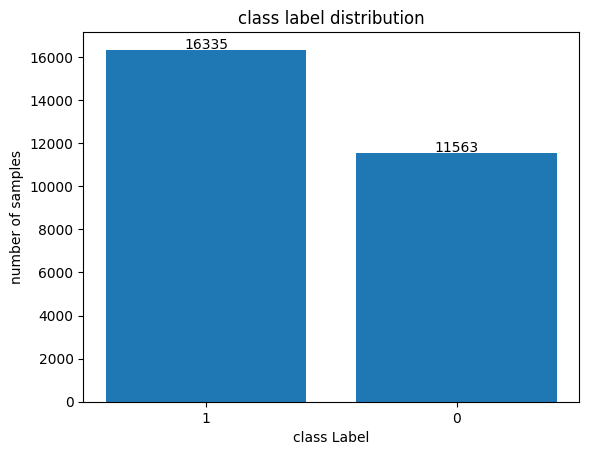

In [ ]:
# Check the class distribution of y

count = y.value_counts()
#set data for the plot
plt.bar(count.index.astype(str),count.values)

#count for each bar
for i, val in enumerate(count.values):
  plt.text(i, val+50, str(val), ha="center")

#figure settings
plt.xlabel("class Label")
plt.ylabel("number of samples")
plt.title("class label distribution")
plt.show()


### Step 2.2: Smaller Dataset Creation (1 marks)

We also want to test if the model would still work if we used less data. Use the `train_test_split` function from sklearn to create a new feature matrix named `X_small` and a new target vector named `y_small` that contain **3%** of the data.

Use random_state = 42

In [ ]:
from sklearn.model_selection import train_test_split

# Create a smaller dataset with 3% of the data (0.5 marks)
x_small, _, y_small, _ = train_test_split(X,y, train_size =0.03, random_state=42)

# Display sizes of X_small and y_small (0.5 marks)
print("shape of smaller X set:", x_small.shape)
print("shape of small Y set:", y_small.shape)


shape of smaller X set: (837, 16)
shape of small Y set: (837,)


### Step 3: Implement Machine Learning Model (3 marks)

1. Import `LogisticRegression` from sklearn
2. Instantiate model `LogisticRegression(max_iter=2000)`
3. Implement the machine learning model with three different datasets:
    - `X` and `y` (1 mark)
    - Only first two columns of `X` and `y` (1 mark)  
    - `X_small` and `y_small` (1 mark)

### Step 4: Test Model (3 x 3 = 9 marks)

Calculate the following for the **three different tests** implemented in Step 3:
1. data size (0.5 mark)
2. number of training samples (0.5 mark)
3. number of testing samples (0.5 mark)
4. training accuracy (0.5 mark)
5. testing accuracy (0.5 mark)
6. log loss (0.5 mark)

### Step 5.1: Visualize Results (2 marks)

1. Create a pandas DataFrame `results` with columns: Data size, training samples, testing samples, training accuracy, testing accuracy, log loss
2. Add these columns for each dataset to the `results` DataFrame
3. Print `results`

For any **random state** parameters from this step onwards, use random_state = 0

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss

# Complete steps 3, 4, and 5.1 in this code block
# Note: 70% training set, 30% testing set
# Create a function that calculates all required information

model = LogisticRegression(max_iter=2000)
results = pd.DataFrame(columns=["Data size", "Training samples", "Testing samples",
                               "Training accuracy", "Testing accuracy", "Log loss"])

def evaluate_model(data_tuple):
  X_data, y_data, label = data_tuple

  #split dataset 70%, 30%
  X_train, X_test, y_train, y_test = train_test_split(
      X_data, y_data, test_size =0.3, random_state =0
  )

  #fit model
  model.fit(X_train, y_train)

  #predictions
  y_train_pred = model.predict(X_train)
  y_test_pred = model.predict(X_test)
  y_test_proba = model.predict_proba(X_test)


  #calculate metrics
  train_acc = accuracy_score(y_train, y_train_pred)
  test_acc = accuracy_score(y_test, y_test_pred)
  loss = log_loss(y_test, y_test_proba)

  #store results
  results.loc[len(results)] = [
        label,
        len(X_train),
        len(X_test),
        round(train_acc, 4),
        round(test_acc, 4),
        round(loss, 4)
    ]

  return X_train, X_test, y_train, y_test


# Test 1: Full dataset (X and y)
evaluate_model((X,y,"Full dataset"))

# Test 2: Only first two columns of X and y
evaluate_model((X.iloc[:,:2],y,"First 2 features"))

# Test 3: Small dataset (X_small and y_small)
evaluate_model((x_small, y_small, "Small dataset"))

print(results)

          Data size  Training samples  Testing samples  Training accuracy  \
0      Full dataset             19528             8370             0.8469   
1  First 2 features             19528             8370             0.6317   
2     Small dataset               585              252             0.8444   

   Testing accuracy  Log loss  
0            0.8461    0.3484  
1            0.6342    0.6527  
2            0.8294    0.3770  


### Step 5.2: Visualize Classification Errors (3 marks)

In this section, print the confusion matrix and the classification report to investigate the number of false positives vs. false negatives. Use the full dataset for this analysis.

In [ ]:
# Retrieve target vector and predicted values for testing set using full dataset
# (1 marks)
# Note: 70% training set, 30% testing set
#split dataset
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X,y, test_size =0.3, random_state =0
)

#model training
model_full = LogisticRegression(max_iter=2000)
model_full.fit(X_train_full, y_train_full)

#prediction on test set
y_test_pred_full = model_full.predict(X_test_full)




Confusion Matrix: [[2698  738]
 [ 550 4384]]


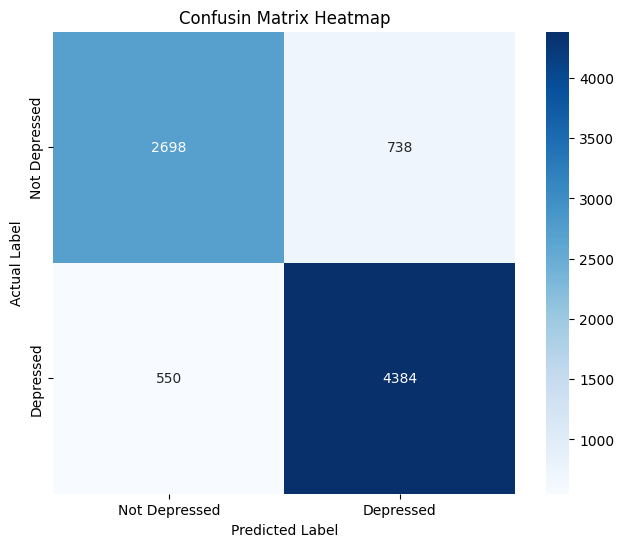

In [ ]:
from sklearn.metrics import confusion_matrix
# Calculate confusion matrix: confusion_matrix()
# (1 marks)

#confusion matrix
conf_mat = confusion_matrix(y_test_full, y_test_pred_full)
print("Confusion Matrix:", conf_mat)

# Print confusion matrix using a heatmap: sns.heatmap()
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat,
           xticklabels=['Not Depressed', 'Depressed'],
           yticklabels=['Not Depressed', 'Depressed'],
           square=True,
           annot=True,
           cbar=True,
           fmt='d',
           cmap='Blues')
plt.xlabel( "Predicted Label"  )
plt.ylabel( "Actual Label"  )
plt.title( "Confusin Matrix Heatmap"  )
plt.show()

In [ ]:
from sklearn.metrics import classification_report
# Print classification report: classification_report()
# (1 marks)
#classification report
cr = classification_report(y_test_full, y_test_pred_full)
print("\nClassification Report:", cr)



Classification Report:               precision    recall  f1-score   support

           0       0.83      0.79      0.81      3436
           1       0.86      0.89      0.87      4934

    accuracy                           0.85      8370
   macro avg       0.84      0.84      0.84      8370
weighted avg       0.85      0.85      0.85      8370



### Additional Models Comparison (2 marks)

Let's compare the Logistic Regression with Naive Bayes and K-Nearest Neighbors models on the same dataset.

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# Compare Logistic Regression, Naive Bayes, and KNN models
# Initialize models (0.5 marks)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0, stratify=y
)


models = {
  "Logistic Regression": LogisticRegression(max_iter = 2000),
  "Gaussian Naive Bayes": GaussianNB(),
  "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5)
}

# Train and evaluate each model using the full dataset (0.5 marks)
model_results = {}

for name, model_instance in models.items():
    # Train the model
    model_instance.fit(X_train, y_train)

    # Make predictions
    y_pred = model_instance.predict(X_test)

    # Calculate accuracy
    acc = accuracy_score(y_test, y_pred)
    model_results[name] = acc

    # Print results
    print(f"{name} Accuracy: {acc:.4f}")



Logistic Regression Accuracy: 0.8479
Gaussian Naive Bayes Accuracy: 0.6465
K-Nearest Neighbors Accuracy: 0.7538


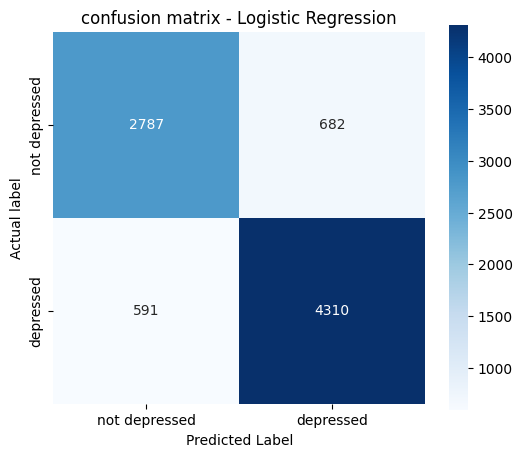

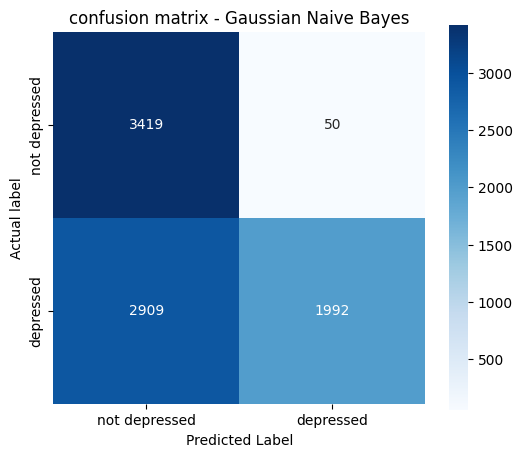

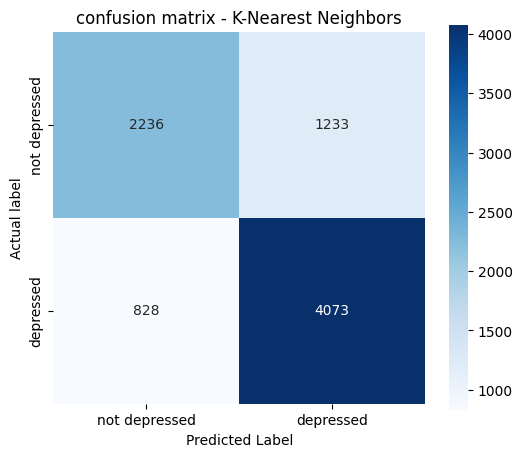

In [ ]:
# Visualize confusion matrices for all models (You can use heatmap again)
# (1 marks)

for name, model_instance in models.items():
  #prediction on test
  y_pred = model_instance.predict(X_test)
  #confusion
  conf_mat = confusion_matrix(y_test, y_pred)

  #heatmap
  plt.figure(figsize=(6,5))
  sns.heatmap(conf_mat,
              annot = True,
              fmt = "d",
              cmap = "Blues",
              xticklabels = ["not depressed","depressed"],
              yticklabels = ["not depressed", "depressed"],
              square = True)

  plt.xlabel("Predicted Label")
  plt.ylabel("Actual label")
  plt.title(f"confusion matrix - {name}")
  plt.show()


### Questions and Analysis (7 marks)

1. Is the dataset balanced? Does it affect model performance? (1 mark)
2. Does the model overfit or underfit for each of the 3 cases? (1 marks)  
3. How do the training and testing accuracy change depending on the amount of data used? Explain with values. (1 mark)
4. In this case, what do a false positive and a false negative represent? Which one is worse? (1 marks)
5. Based on your answer to question 4, would you want to maximize precision or recall? How would you do this? (1 marks)
6. Based on the Log Loss for each of the 3 cases, what can you say about the model in each instance? What is potentially causing these differences? (1 marks)
7. Compare the performance of Logistic Regression, Naive Bayes, and K-Nearest Neighbors models. Which performs best and why? Explain based on each algorithm's characteristics and assumptions. (1 marks)

### Answer here (double click)


## Question 1:
The dataset counts are as follows:
Depressed = 16335
Not Depressed = 11563
therefore, they are not perfectly banalnced, roughly 58% are depressed and 41% not. This will create a slight calss imblanace that may cause more depressed predictions. While Logistic Regression handles imbalance relatively well, metrics may slighlty overestimate performance. Precision, recall and F1 scores are likely more reliable than accuracy.


##Question 2:
On the full dataset, training accuracy is 0.8469, test accuracy is 0.8461. These are relatively equal meaning there is no overfitting and the model will generalize well.  

For the first 2 features, Training accuracy is 0.6317, and test accuracy is 0.6342. This model may be underfit, with too few features to capture a pattern well.

On the small dataset, training accuracy is 0.8444 and test accuracy is 0.8294, where the training is slightly higher than testing. This shows some overfitting, although minimal. The small sample size may result in higher variance.


##Question 3:
The results above would suggest that more data and relevant features lead to improved accuract and reduced underfitting. Limiting either of these factors may scew the model resutls.

##Question 4:
False Positive - model predics a positive otucome (derpressed) when the studen is not.

False Negative - model predicts negative outcome (not depressed) when the student is actually depressed.

In this context, a false negative would be worse since that means that a student needing help was missed, which can be devestating when considering mental health.


##Question 5:
We would want to minimize false negatives. This maximizes recall for the depressed class. To accomplish this, we can adjust the decision threshold of LR mdoel to be lower fro the depressed class. We could weight the class to penalize the model missing points and we can incorporate other metrics like F1 scores rather than jsut accuracy.

##Question 6:
Log loss increases when the model is less certain or makes more mistakes, reflecting insufficient features or small samples sizes. This can be seen when comparing the first 2 features and the small dataset to the full dataset - both of those are higher than the full dataset.

##Question 7:

LR:
- performs well on the dataset - accuracy 84%
- good for linearly sperable data and probability outputs
- can handle numerous features

GNB:
- simpler model
- assumes independence
- may underperform if features are correlated (likely the case here)

KNN:
- depends on k and featuere scaling
- can overfit on small datasets or high-dimensional data
- sensitive to noise

LR likely performs better here beacuse the dataset has numerous dimensions.



---
---

# **PART 3: MNIST Handwritten Digit Classification using MLP & CNN (30 Marks)**

This part compares two neural network architectures for handwritten digit classification:
- **Multi-Layer Perceptron (MLP)**: A traditional fully-connected neural network
- **Convolutional Neural Network (CNN)**: A specialized architecture for image processing


The MNIST database of handwritten digits has a training set of 60,000 examples, and a test set of 10,000 examples. This dataset we're using uses the work of Joseph Redmon to provide the MNIST dataset in a CSV format. And it can be downloaded from https://www.kaggle.com/datasets/hojjatk/mnist-dataset

The dataset consists of two files:
- mnist_train.csv
- mnist_test.csv

The mnist_train.csv file contains the 60,000 training examples and labels. The mnist_test.csv contains 10,000 test examples and labels. Each row consists of 785 values: the first value is the label (a number from 0 to 9) and the remaining 784 values are the pixel values (a number from 0 to 255).

Acknowledgements:
- Yann LeCun, Courant Institute, NYU
- Corinna Cortes, Google Labs, New York
- Christopher J.C. Burges, Microsoft Research, Redmond

![MNIST dataset](https://upload.wikimedia.org/wikipedia/commons/b/b1/MNIST_dataset_example.png)

We'll train both models on the MNIST dataset and compare their performance.

### Step 1: Library Imports

Import the necessary libraries for data processing, model building, and evaluation.

In [ ]:
# Library imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

### Step 2: Dataset Loading (2 marks)

Load the MNIST dataset from CSV files. The MNIST dataset contains 70,000 images of handwritten digits (0-9).

Then visualize some sample images.

In [ ]:
# Load MNIST dataset from CSV files

#load files with .read_csv
train_csv_path = pd.read_csv('Lab_Assignment_2/part3-data/mnist_train.csv')
test_csv_path = pd.read_csv('Lab_Assignment_2/part3-data/mnist_test.csv')

# Load training data
# The first line is the label, the rest are pixel values
# (0.5 marks)

train_data = train_csv_path
#labels in first column
y_train = train_data.iloc[:,0]

#data
X_train = train_data.iloc[:,1:].values


# CSV stores each image as a single row of 784 pixels, but we need 28x28 matrix for image processing
# Reshape from flat array (784,) to 2D image format (28, 28)
# (0.5 marks)
X_train = X_train.reshape(-1,28,28)

# Load test data (0.5 marks)
test_data = test_csv_path
y_test = train_data.iloc[:,0]
X_test = train_data.iloc[:, 1:].values

# Reshape test data to match training data format (0.5 marks)
X_test = X_test.reshape(-1,28,28)

# Display the shapes of training and test sets
print(f"Training data shapes are:\n X: {X_train.shape}\n Y: {y_train.shape}")
print(f"Test data shapes are:\n X:{X_test.shape}\n Y:{y_test.shape}")


Training data shapes are:
 X: (60000, 28, 28)
 Y: (60000,)
Test data shapes are:
 X:(60000, 28, 28)
 Y:(60000,)


Let's visualize some sample images to understand what our models will be learning from.

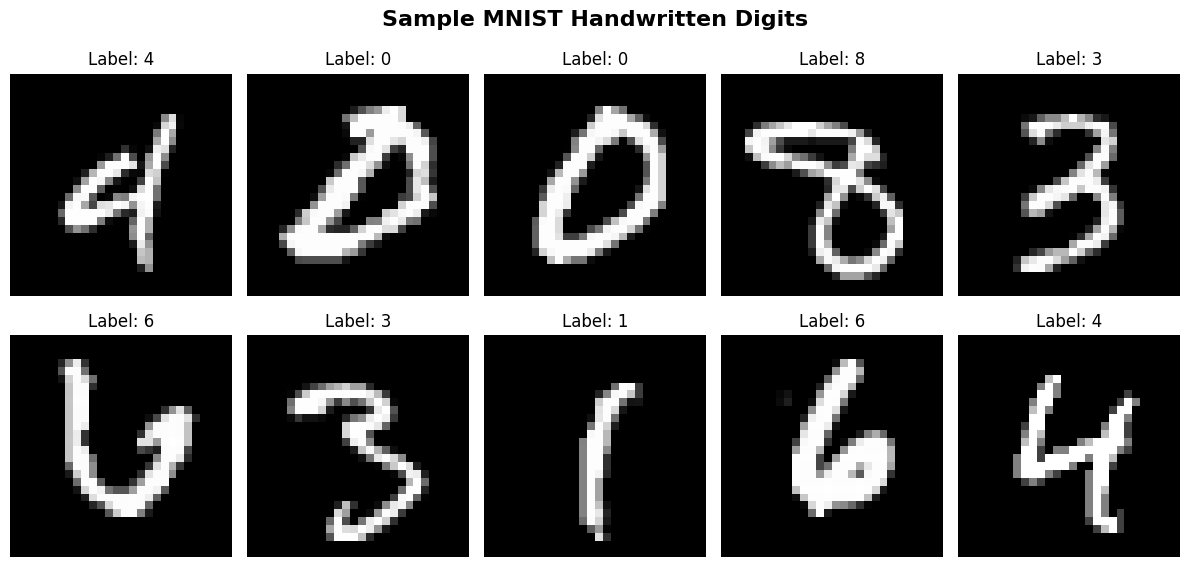

In [ ]:
# Visualize sample images from the dataset as a grid of 10 images (2 rows x 5 columns)
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
fig.suptitle('Sample MNIST Handwritten Digits', fontsize=16, fontweight='bold')

# Display 10 random samples
# Use a loop
for i in range(10):
    row = i // 5
    col = i % 5

    # Get a random sample
    idx = np.random.randint(0, len(X_train))
    image = X_train[idx]
    label = y_train[idx]

    # Display the image
    axes[row, col].imshow(image, cmap='gray')
    axes[row, col].set_title(f'Label: {label}', fontsize=12)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

### Step 3: Data Preprocessing (1 mark)

Normalize pixel values to [0,1] range and convert labels to one-hot encoding for multi-class classification.

Why normalize? Neural networks work better with smaller input values (0-1 vs 0-255)
- Faster convergence during training
- Prevents gradient explosion/vanishing
- Makes learning more stable

Why one-hot? Transform labels from integers (0,1,2...9) to binary vectors

- Example: label "3" becomes [0,0,0,1,0,0,0,0,0,0]

- This allows softmax output layer to predict probabilities for each class

In [ ]:
# Normalize pixel values from [0, 255] to [0, 1] range
# hint: divide by 255.0 (0.5 marks)

X_train_normalized = X_train/ 255
X_test_normalized = X_test / 255

# Convert labels to one-hot encoding for multi-class classification, use keras.utils.to_categorical to do it
# (0.5 marks)
#import library
from tensorflow.keras.utils import to_categorical

#one-hot encoding conversion
num_classes = 10
y_train_categorical = to_categorical(y_train, num_classes=10)
y_test_categorical = to_categorical(y_test, num_classes=10)


### Step 4: MLP Model Creation and Training (7 marks)

Create a Multi-Layer Perceptron model with fully connected layers. This model treats each pixel as an independent feature.

This created model can be used for fit, predict and evaluate the dataset through calling mlp_model.fit(), mlp_model.predict() and mlp_model.evaluate(), you can consider it as a inbuild model right now.

Hint: We will use tf.keras.layers function, and add flatten layer, hidden layer, dropout layer, hidden layer, dropout layer and output layer.

In [ ]:
# Create MLP model, add each of layers with their parameters

def create_mlp_model():
    model = tf.keras.Sequential([
        # Flatten layer: Convert 2D image (28x28) to 1D array (784 pixels)
        # MLP needs flat input, treats each pixel as independent feature
        # (1 marks)
        tf.keras.layers.Flatten(input_shape=(28, 28)),

        # First hidden layer: 128 neurons with ReLU activation
        # ReLU = max(0, x), helps with vanishing gradient problem
        # (1 marks)
         tf.keras.layers.Dense(128, activation= "relu"),

        # Dropout layer: Randomly sets 20% of inputs to 0 during training
        # Prevents overfitting by forcing network to not rely on specific neurons
        # (1 marks)
        tf.keras.layers.Dropout(0.2),


        # Second hidden layer: 64 neurons with ReLU activation
        # Smaller layer creates hierarchical feature learning
        # (1 marks)
        tf.keras.layers.Dense(64, activation="relu"),

        # Another dropout layer for regularization, same with above
        # (1 marks)
        tf.keras.layers.Dropout(0.2),

        # Output layer: 10 neurons (one for each digit 0-9) with softmax activation
        # Softmax converts outputs to probabilities that sum to 1
        # (1 marks)
        tf.keras.layers.Dense(10, activation="softmax")

    ])

    # Compile model with optimizer, loss function, and metrics
    # Adam: adaptive learning rate optimizer
    # Categorical crossentropy: loss for multi-class classification
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Creating the mlp model, and you can use this model to fit and evaluate with the dataset in the following process.
# You don't need to change anything here.
mlp_model = create_mlp_model()
print("MLP Model created")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


MLP Model created


**Use .fit() to train MLP model**

In [ ]:
# EPOCHS: Number of complete passes through entire training dataset, use 5 epochs
# (0.5 marks)
EPOCHS = 5

# BATCH_SIZE: Number of samples processed before updating model weights
# Larger batch = more stable gradients but more memory usage
# Use 128 as batch size
# (0.5 marks)
BATCH_SIZE = 128

# Train MLP model using mlp_model we compile.
# Use 10% of training data for validation, validation_split=0.1
# Silent training (no progress output), verbose=0
mlp_history = mlp_model.fit(
    X_train_normalized, y_train_categorical,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=0
)


print("MLP training completed")

MLP training completed


### Step 5: CNN Model Creation and Training (7 marks)

Create a Convolutional Neural Network with convolutional and pooling layers. This model preserves spatial relationships between pixels.

#### Fundamental Difference between MLP and CCN:

**Key Architectural Differences:**
- **MLP**: Input → Flatten → Dense layers → Output (treats pixels independently)
- **CNN**: Input → Reshape → Conv+Pool layers → Flatten → Dense layers → Output (learns spatial patterns first)

**The CNN Advantage:**
1. **Convolutional Layers**: Extract spatial features (edges, curves, shapes) that MLP cannot detect
2. **Pooling Layers**: Provide translation invariance and reduce computational load
3. **Feature Hierarchy**: Early layers detect simple patterns, deeper layers combine them into complex features
4. **Parameter Sharing**: Same filter applied across entire image, making CNN more efficient

**Why CNNs End with Dense Layers:**
- Convolutional layers act as **feature extractors** (learn "what" is in the image)
- Dense layers act as **classifiers** (decide "which digit" based on extracted features)
- This is a common pattern: **Feature Extraction (CNN) + Classification (MLP)**

**The Real Difference:**
- **MLP Dense layers**: Work with raw pixel values (784 individual numbers)
- **CNN Dense layers**: Work with high-level spatial features learned by convolutional layers

Hint: We will use tf.keras.layers function again, reshape it firstly, then add Conv2D, MaxPooling2D, Conv2D, MaxPooling2D, Conv2D, and do same last two steps like MLP.

In [ ]:
from matplotlib.cbook import flatten
# Similar process with creating MLP model
# Create CNN model - Different from MLP in how it processes spatial information
def create_cnn_model():
    model = tf.keras.Sequential([
        # Reshape: Add channel dimension (28, 28, 1) for grayscale images (0.5 marks)
        tf.keras.layers.Reshape((28, 28, 1), input_shape=(28, 28)),

        # Conv2D: Applies 32 filters of size 3x3 to detect local patterns (edges, curves) (1 marks)
        tf.keras.layers.Conv2D(32, (3, 3), activation= "relu"),

        # Reduces image size by taking maximum value in 2x2 regions (0.5 marks)
        tf.keras.layers.MaxPooling2D((2,2)),


        # Conv2D: Second convolutional layer, 64 filters learn more complex patterns (1 marks)
        tf.keras.layers.Conv2D(64, (3,3), activation = "relu"),


        # MaxPooling2D: Another pooling layer to further reduce spatial dimensions (0.5 marks)
        tf.keras.layers.MaxPooling2D((2,2)),


        # Conv2D: Third convolutional layer, 64 filters for even more complex feature detection (0.5 marks)
        tf.keras.layers.Conv2D(64, (3,3), activation = "relu"),


        # Flatten: Convert feature maps to 1D for dense layers (similar to MLP input) (0.5 marks)
        tf.keras.layers.Flatten(),


        # Dense layers: Same as MLP, but now working with CNN-extracted features (0.5 marks)
        tf.keras.layers.Dense(64, activation= "relu"),
        tf.keras.layers.Dense(10, activation = "softmax")

    ])

    # Same compile step with MLP (1 marks)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Create the mlp model, and you can use this model to fit and evaluate with the dataset in the following process.
# You don't need to change anything here.
cnn_model = create_cnn_model()
print("CNN Model created")

CNN Model created


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


**Use .fit() to train CNN model**

In [ ]:
# Train CNN model using cnn_model we compile, same parameters as MLP
# (1 marks)
cnn_history = cnn_model.fit(
    X_train_normalized, y_train_categorical,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=0
)

print("CNN training completed")


CNN training completed


### Step 6: Model Evaluation and Comparison (4 marks)

Evaluate both models on the test set and compare their performance with visualizations.

Using .predict(), .evaluate() functions as we used in part2

In [ ]:
# Evaluate both models on test set
# Get test loss and accuracy, make predictions, convert probabilities to class labels

# your code here for mlp (1.5 marks)
mlp_test_loss, mlp_test_acc = mlp_model.evaluate(X_test_normalized, y_test_categorical, verbose=0)
print(f"MLP Test Loss: {mlp_test_loss:.4f}, Test Accuracy: {mlp_test_acc:.4f}")

mlp_predictions = mlp_model.predict(X_test, verbose=0)

# Note: The model outputs class probabilities (softmax). We convert these to discrete class labels by taking the index of the maximum probability (argmax).
# These integer labels (0-9) are required for computing accuracy, building confusion matrices, and for plotting / comparing predicted vs true labels.
mlp_predicted_classes = np.argmax(mlp_predictions, axis=1)

# your code here for cnn (1.5 marks)
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(X_test_normalized, y_test_categorical, verbose=0)
print(f"CNN Test Loss: {cnn_test_loss:.4f}, Test Accuracy: {cnn_test_acc:.4f}")

cnn_predictions = cnn_model.predict(X_test, verbose=0)

# Similarly, convert CNN predicted probabilities to class labels
cnn_predicted_classes = np.argmax(cnn_predictions, axis=1)


# Display Results
print(f"MLP Accuracy: {mlp_test_acc:.4f}")
print(f"CNN Accuracy: {cnn_test_acc:.4f}")



MLP Test Loss: 0.0584, Test Accuracy: 0.9828
CNN Test Loss: 0.0210, Test Accuracy: 0.9940
MLP Accuracy: 0.9828
CNN Accuracy: 0.9940


Performance comparison visualization

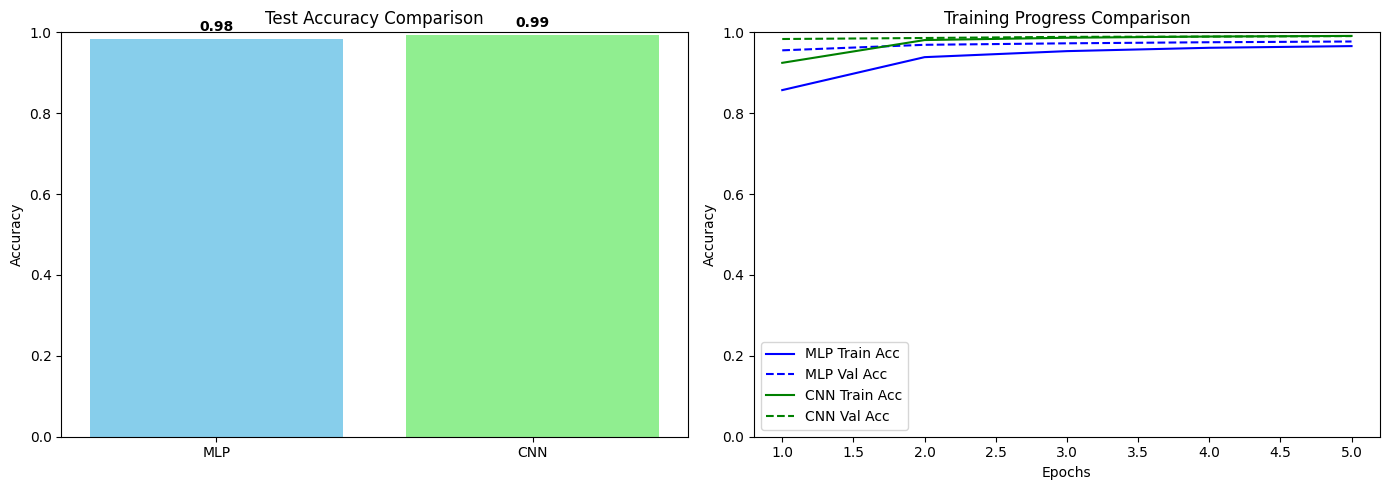

In [ ]:
# Create side-by-side bar chart for model accuracy comparison and line plot for training progress comparison
# (1 marks)
# put them in a single figure horizontally
# Add titles, labels, legends for clarity
# hint: use .history() function to get training history from the training step

model_names = ['MLP', 'CNN']
test_accuracies = [mlp_test_acc, cnn_test_acc]

#data for line plot pulled from the history
epochs_mlp = range(1, len(mlp_history.history['accuracy']) + 1)
epochs_cnn = range(1, len(cnn_history.history['accuracy']) + 1)

# Create horizontal figures
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# bar chart set up
axes[0].bar(model_names, test_accuracies, color=['skyblue', 'lightgreen'])
axes[0].set_ylim(0, 1)
axes[0].set_title("Test Accuracy Comparison")
axes[0].set_ylabel("Accuracy")
for i, acc in enumerate(test_accuracies):
    axes[0].text(i, acc + 0.02, f"{acc:.2f}", ha='center', fontweight='bold')

# line plot for training
axes[1].plot(epochs_mlp, mlp_history.history['accuracy'], label='MLP Train Acc', color='blue')
axes[1].plot(epochs_mlp, mlp_history.history['val_accuracy'], label='MLP Val Acc', color='blue', linestyle='--')
axes[1].plot(epochs_cnn, cnn_history.history['accuracy'], label='CNN Train Acc', color='green')
axes[1].plot(epochs_cnn, cnn_history.history['val_accuracy'], label='CNN Val Acc', color='green', linestyle='--')

axes[1].set_title("Training Progress Comparison")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()



### Step 7: Prediction Analysis Visualization (4 marks)

Let's examine some specific predictions to see how each model performs on individual samples.

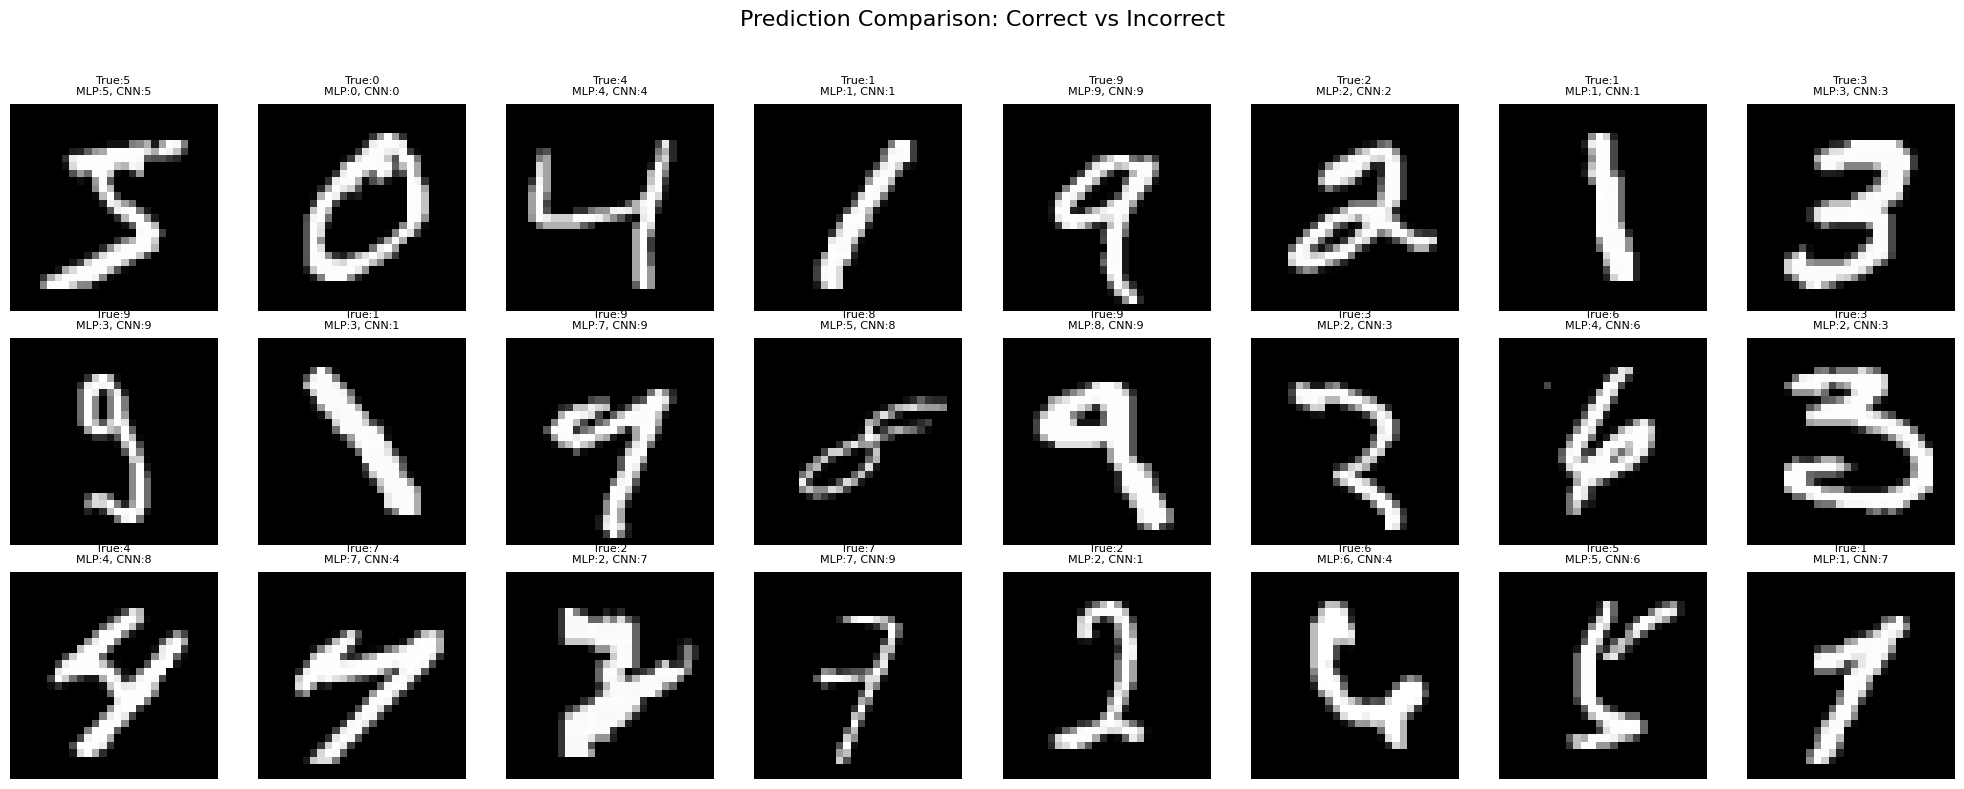

In [ ]:
# Visualize correct and incorrect predictions, create a 3x8 grid
# First row: Both models correct
# Second row: CNN correct, MLP wrong
# Third row: MLP correct, CNN wrong

# corrected model for both
both_correct = (mlp_predicted_classes == y_test) & (cnn_predicted_classes == y_test)
both_correct_indices = np.where(both_correct)[0][:8]

# CNN corrected, MLP wrong
cnn_correct_mlp_wrong = (cnn_predicted_classes == y_test) & (mlp_predicted_classes != y_test)
cnn_correct_mlp_wrong_indices = np.where(cnn_correct_mlp_wrong)[0][:8]

# CNN wrong, MPL corrected
mlp_correct_cnn_wrong = (mlp_predicted_classes == y_test) & (cnn_predicted_classes != y_test)
mlp_correct_cnn_wrong_indices = np.where(mlp_correct_cnn_wrong)[0][:8]


# creating subplots
fig, axes = plt.subplots(3, 8, figsize=(20, 8))
fig.suptitle("Prediction Comparison: Correct vs Incorrect", fontsize=16)

# both correct
for i, idx in enumerate(both_correct_indices):
    axes[0, i].imshow(X_test[idx], cmap='gray')
    axes[0, i].axis('off')
    axes[0, i].set_title(f"True:{y_test[idx]}\nMLP:{mlp_predicted_classes[idx]}, CNN:{cnn_predicted_classes[idx]}",
                         fontsize=8)

# CNN correct, MLP wrong
for i, idx in enumerate(cnn_correct_mlp_wrong_indices):
    axes[1, i].imshow(X_test[idx], cmap='gray')
    axes[1, i].axis('off')
    axes[1, i].set_title(f"True:{y_test[idx]}\nMLP:{mlp_predicted_classes[idx]}, CNN:{cnn_predicted_classes[idx]}",
                         fontsize=8)

# MPL correct, CNN wrong
for i, idx in enumerate(mlp_correct_cnn_wrong_indices):
    axes[2, i].imshow(X_test[idx], cmap='gray')
    axes[2, i].axis('off')
    axes[2, i].set_title(f"True:{y_test[idx]}\nMLP:{mlp_predicted_classes[idx]}, CNN:{cnn_predicted_classes[idx]}",
                         fontsize=8)
#adjustments for styling
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Questions and Analysis (5 marks)

1. Which model performed better and why? (1 marks)
2. How do the training curves compare between the two models? (1 marks)
3. What does the accuracy improvement percentage tell us? (1 marks)
4. Why didn't we need many epochs for good results? (1 marks)
5. What would happen with more complex images? (1 marks)

## Question 1:
The MPL accuracy was 98.28%, and higher loss. The CNN accuracy was 99.40% and lower loss (0.0210), therefore the CNN model performed better. This is likely because CNNs are designed to capture spation hierarchies in images through convolutional layers. The local patterns present are better represented than in MPL, which treats every pixel independently.


## Question 2:
Based on the training curves demonstrated, the CNN converged faster and smoother than teh MLP. The CNN has convolutional layers taht efficiently capture features so fewer epochs are needed. MLP shows more fluctuations because it relies entirely on dense layers - meaning easier overfitting/underfitting if the network isn't wide/deep enough. The accuracy of CNN is closer to training accuracy, meaning better generalization.

## Question 3:
Accuacry improvement is 1.14%. Even though this percentage is minor, in high-accuracy regimes this could represent a significant reduction in errors.

## Question 4:
The data scale is simple with a small grayscale and clear patterns. Both models can learn the necessary features quickly. The risk of overfitting risk is low with small, clean datasets, allowing it to converge quickly.

## Question 5:
The accuracy would drop if we used the same MLP and CNN. More complex images have larger dimensions, color channels, and more intricate patterns. MLP ignore spation structure, CNNs need deeper networks, more filters and possible data augmentation. With more complex images, training time would also increase.
